# DATA01 Executive Search Analytics Assignment

## Notebook 01: Datenimport, Debitor-Feature-Matrix und erste Debitor-EDA

Dieses Notebook lädt die bereinigte Analysebasis, prüft die wichtigsten Grundannahmen und erzeugt eine erste Debitor-Feature-Matrix. Anschließend folgt eine schlanke EDA auf Debitor-Ebene als Grundlage für die nächsten Schritte in Data Cleaning und Feature Engineering.

In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [155]:
file_path = "../data/raw/UDB - 2010 - 2025 - prep - complete.xlsx"
df = pd.read_excel(file_path)

print("Zeilen:", df.shape[0])
print("Spalten:", df.shape[1])

Zeilen: 15262
Spalten: 14


In [156]:
df.columns.tolist()

['ID',
 'Datum',
 'Rechnungsnummer',
 'Vertragsart',
 'Umsatzart',
 'Umsatzart_Sub',
 'Jobkategorie',
 'Branche',
 'Debitor',
 'Netto_Betrag_Indexed',
 'Nebenkosten_Indexed',
 'Placement',
 'OTE',
 'Fuehrungsposition']

In [157]:
df.head()

,ID,Datum,Rechnungsnummer,Vertragsart,Umsatzart,Umsatzart_Sub,Jobkategorie,Branche,Debitor,Netto_Betrag_Indexed,Nebenkosten_Indexed,Placement,OTE,Fuehrungsposition
0,854,2010-08-09,E-PCVII-10-7036,Prozent - 3 Raten,1 Personalberatung,Start,Spezialist (Kerngeschäft),Industrial,Debitor 377,0.051282,0.0,False,NaN,False
1,860,2010-08-12,E-PCII-10-2001,Prozent - 3 Raten,1 Personalberatung,Start,C-Level,Industrial,Debitor 547,0.055556,0.0,False,NaN,False
2,861,2010-08-12,E-PCI-10-1085,Pauschalhonorar,1 Personalberatung,Erfolgsauftrag,C-Level,Digital & Technology,Debitor 419,0.235043,0.0,True,NaN,False
3,862,2010-08-13,E-PCI-10-1086,Prozent - 3 Raten,1 Personalberatung,Start,Vertrieb/Presales/Marketing,Digital & Technology,Debitor 185,0.056974,0.0,False,NaN,False
4,863,2010-08-13,E-PCI-10-1087,Prozent - 3 Raten,1 Personalberatung,Start,Vertrieb/Presales/Marketing,Digital & Technology,Debitor 185,0.056974,0.0,False,NaN,False


In [158]:
# Datumsfeld in ein konsistentes Format überführen

df["Datum"] = pd.to_datetime(df["Datum"], errors="coerce")

print("Frühestes Datum:", df["Datum"].min())
print("Spätestes Datum:", df["Datum"].max())
print("Fehlende Datumswerte:", df["Datum"].isna().sum())

Frühestes Datum: 2010-01-04 00:00:00
Spätestes Datum: 2025-12-31 00:00:00
Fehlende Datumswerte: 0


In [159]:
print("Placement:")
print(df["Placement"].value_counts(dropna=False))
print()

print("Fuehrungsposition:")
print(df["Fuehrungsposition"].value_counts(dropna=False))

Placement:
Placement
False    11373
True      3889
Name: count, dtype: int64

Fuehrungsposition:
Fuehrungsposition
False    12230
True      3032
Name: count, dtype: int64


In [160]:
def get_mode(series):
    series = series.dropna().astype(str).str.strip()
    if series.empty:
        return np.nan
    return series.mode().iloc[0]

In [161]:
# Debitor-Feature-Matrix aufbauen

debitor_features = df.groupby("Debitor").agg(
    invoice_count=("Rechnungsnummer", "nunique"),
    first_invoice_date=("Datum", "min"),
    last_invoice_date=("Datum", "max"),
    active_years_count=("Datum", lambda x: x.dt.year.nunique()),
    net_index_sum=("Netto_Betrag_Indexed", "sum"),
    net_index_mean=("Netto_Betrag_Indexed", "mean"),
    nk_index_sum=("Nebenkosten_Indexed", "sum"),
    nk_index_mean=("Nebenkosten_Indexed", "mean"),
    placement_count=("Placement", lambda x: x.fillna(False).sum()),
    placement_rate=("Placement", lambda x: x.fillna(False).mean()),
    leadership_count=("Fuehrungsposition", lambda x: x.fillna(False).sum()),
    leadership_rate=("Fuehrungsposition", lambda x: x.fillna(False).mean()),
    dominant_contract_type=("Vertragsart", get_mode),
    dominant_revenue_subtype=("Umsatzart_Sub", get_mode),
    dominant_job_category=("Jobkategorie", get_mode),
    dominant_industry=("Branche", get_mode)
).reset_index()

In [162]:
# Zusätzliche Zeitmerkmale ergänzen

debitor_features["active_days"] = (
    debitor_features["last_invoice_date"] - debitor_features["first_invoice_date"]
).dt.days

analysis_date = pd.Timestamp("2025-12-31")

debitor_features["recency_days"] = (
    analysis_date - debitor_features["last_invoice_date"]
).dt.days

In [163]:
print("Anzahl Debitoren:", debitor_features.shape[0])
print("Anzahl Features:", debitor_features.shape[1])

Anzahl Debitoren: 1364
Anzahl Features: 19


In [164]:
debitor_features.head()

,Debitor,invoice_count,first_invoice_date,last_invoice_date,active_years_count,net_index_sum,net_index_mean,nk_index_sum,nk_index_mean,placement_count,placement_rate,leadership_count,leadership_rate,dominant_contract_type,dominant_revenue_subtype,dominant_job_category,dominant_industry,active_days,recency_days
0,Debitor 1,101,2010-11-25,2025-11-27,16,5.974359,0.059152,0.581197,0.005754,30,0.29703,0,0.000000,Pauschal - 3 Raten,Start,Spezialist (Kerngeschäft),Digital & Technology,5481,34
1,Debitor 10,1,2018-11-27,2018-11-27,1,0.042735,0.042735,0.000000,0.000000,1,1.00000,0,0.000000,Pauschalhonorar,Erfolgsauftrag,Spezialist (Kerngeschäft),Digital & Technology,0,2591
2,Debitor 100,36,2017-11-15,2025-09-26,7,2.910427,0.080845,0.338704,0.009408,9,0.25000,12,0.333333,Prozent - 3 Raten,Start,Spezialist (Kerngeschäft),Financial Services,2872,96
3,Debitor 1000,2,2012-10-31,2013-03-21,2,0.153846,0.076923,0.002564,0.001282,1,0.50000,0,0.000000,Prozent mit Anzahlung,Abschluss,Vertrieb/Presales/Marketing,Digital & Technology,141,4668
4,Debitor 1001,4,2011-07-28,2011-11-15,1,0.307692,0.076923,0.000000,0.000000,0,0.00000,0,0.000000,Prozent - 3 Raten,Präsentation,C-Level,Financial Services,110,5160


In [165]:
# Erste Plausibilitätsprüfung zentraler numerischer Merkmale

debitor_features[
    [
        "invoice_count",
        "active_years_count",
        "net_index_sum",
        "placement_count",
        "placement_rate",
        "leadership_rate",
        "active_days",
        "recency_days"
    ]
].describe()

,invoice_count,active_years_count,net_index_sum,placement_count,placement_rate,leadership_rate,active_days,recency_days
count,1364.000000,1364.000000,1364.000000,1364.000000,1364.000000,1364.000000,1364.000000,1364.000000
mean,11.142962,2.390029,0.918982,2.851173,0.231396,0.259176,727.978739,2092.298387
std,20.704310,1.950695,1.561713,5.882363,0.206170,0.377950,1086.894672,1673.240204
min,0.000000,1.000000,-0.071368,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,1.000000,0.198611,0.000000,0.000000,0.000000,89.000000,649.750000
50%,5.000000,2.000000,0.413085,1.000000,0.230769,0.000000,260.000000,1645.000000
75%,11.000000,3.000000,0.971474,3.000000,0.333333,0.500000,854.000000,3360.500000
max,257.000000,16.000000,18.944017,72.000000,1.000000,1.000000,5712.000000,5826.000000


## Debitor-EDA

Im nächsten Schritt wird die Debitor-Matrix knapp, aber gezielt geprüft. Der Fokus liegt auf Fehlwerten, Verteilungen und auffälligen Fällen, die für das weitere Data Cleaning relevant sind.

In [166]:
eda_df = debitor_features.copy()

print("Anzahl Debitoren:", eda_df.shape[0])
print("Anzahl Features:", eda_df.shape[1])

Anzahl Debitoren: 1364
Anzahl Features: 19


In [167]:
# Struktur und Datentypen

print("Spalten:")
print(eda_df.columns.tolist())
print()
print("Datentypen:")
print(eda_df.dtypes)

Spalten:
['Debitor', 'invoice_count', 'first_invoice_date', 'last_invoice_date', 'active_years_count', 'net_index_sum', 'net_index_mean', 'nk_index_sum', 'nk_index_mean', 'placement_count', 'placement_rate', 'leadership_count', 'leadership_rate', 'dominant_contract_type', 'dominant_revenue_subtype', 'dominant_job_category', 'dominant_industry', 'active_days', 'recency_days']

Datentypen:
Debitor                                str
invoice_count                        int64
first_invoice_date          datetime64[us]
last_invoice_date           datetime64[us]
active_years_count                   int64
net_index_sum                      float64
net_index_mean                     float64
nk_index_sum                       float64
nk_index_mean                      float64
placement_count                      int64
placement_rate                     float64
leadership_count                     int64
leadership_rate                    float64
dominant_contract_type                 str
dominan

In [168]:
# Fehlwerte je Feature

missing_summary = pd.DataFrame({
    "missing_count": eda_df.isna().sum(),
    "missing_pct": (eda_df.isna().sum() / len(eda_df) * 100).round(2)
}).sort_values(["missing_count", "missing_pct"], ascending=False)

missing_summary

,missing_count,missing_pct
Debitor,0,0.0
invoice_count,0,0.0
first_invoice_date,0,0.0
last_invoice_date,0,0.0
active_years_count,0,0.0
net_index_sum,0,0.0
net_index_mean,0,0.0
nk_index_sum,0,0.0
nk_index_mean,0,0.0
placement_count,0,0.0


In [169]:
# Konstante und fast konstante Features

unique_summary = pd.DataFrame({
    "n_unique": eda_df.nunique(dropna=False)
}).sort_values("n_unique")

unique_summary

,n_unique
dominant_job_category,7
dominant_industry,9
dominant_contract_type,10
active_years_count,15
dominant_revenue_subtype,18
leadership_count,31
placement_count,41
invoice_count,86
leadership_rate,153
placement_rate,157


In [170]:
# Numerische und kategoriale Features trennen

numeric_cols = eda_df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = eda_df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numerische Features:")
print(numeric_cols)
print()
print("Kategoriale Features:")
print(categorical_cols)

Numerische Features:
['invoice_count', 'active_years_count', 'net_index_sum', 'net_index_mean', 'nk_index_sum', 'nk_index_mean', 'placement_count', 'placement_rate', 'leadership_count', 'leadership_rate', 'active_days', 'recency_days']

Kategoriale Features:
['Debitor', 'dominant_contract_type', 'dominant_revenue_subtype', 'dominant_job_category', 'dominant_industry']


C:\Users\jensm\AppData\Local\Temp\ipykernel_33416\3578270278.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = eda_df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


In [171]:
# Deskriptive Statistik für numerische Features

numeric_summary = eda_df[numeric_cols].describe().T
numeric_summary["median"] = eda_df[numeric_cols].median()
numeric_summary["missing_count"] = eda_df[numeric_cols].isna().sum()
numeric_summary["missing_pct"] = (eda_df[numeric_cols].isna().sum() / len(eda_df) * 100).round(2)

numeric_summary

,count,mean,std,min,25%,50%,75%,max,median,missing_count,missing_pct
invoice_count,1364.0,11.142962,20.704310,0.000000,3.000000,5.000000,11.000000,257.000000,5.000000,0,0.0
active_years_count,1364.0,2.390029,1.950695,1.000000,1.000000,2.000000,3.000000,16.000000,2.000000,0,0.0
net_index_sum,1364.0,0.918982,1.561713,-0.071368,0.198611,0.413085,0.971474,18.944017,0.413085,0,0.0
net_index_mean,1364.0,0.089626,0.053661,-0.035684,0.059829,0.077550,0.106838,0.854701,0.077550,0,0.0
nk_index_sum,1364.0,0.052232,0.110286,-0.002082,0.000000,0.018786,0.051282,1.777778,0.018786,0,0.0
nk_index_mean,1364.0,0.005752,0.007302,-0.000045,0.000000,0.003921,0.008547,0.066667,0.003921,0,0.0
placement_count,1364.0,2.851173,5.882363,0.000000,0.000000,1.000000,3.000000,72.000000,1.000000,0,0.0
placement_rate,1364.0,0.231396,0.206170,0.000000,0.000000,0.230769,0.333333,1.000000,0.230769,0,0.0
leadership_count,1364.0,2.222874,4.651639,0.000000,0.000000,0.000000,3.000000,65.000000,0.000000,0,0.0
leadership_rate,1364.0,0.259176,0.377950,0.000000,0.000000,0.000000,0.500000,1.000000,0.000000,0,0.0


In [172]:
# Auffällige Fälle gezielt prüfen

invoice_zero_df = eda_df[eda_df["invoice_count"] == 0]
negative_net_df = eda_df[eda_df["net_index_sum"] < 0]
negative_nk_df = eda_df[eda_df["nk_index_sum"] < 0]

print("Debitoren mit invoice_count = 0:", len(invoice_zero_df))
print("Debitoren mit negativem net_index_sum:", len(negative_net_df))
print("Debitoren mit negativem nk_index_sum:", len(negative_nk_df))

Debitoren mit invoice_count = 0: 1
Debitoren mit negativem net_index_sum: 1
Debitoren mit negativem nk_index_sum: 1


In [173]:
invoice_zero_df.head(10)

,Debitor,invoice_count,first_invoice_date,last_invoice_date,active_years_count,net_index_sum,net_index_mean,nk_index_sum,nk_index_mean,placement_count,placement_rate,leadership_count,leadership_rate,dominant_contract_type,dominant_revenue_subtype,dominant_job_category,dominant_industry,active_days,recency_days
312,Debitor 128,0,2012-03-06,2012-03-06,1,0.0,0.0,0.0,0.0,1,1.0,0,0.0,N/V,Replacement,Corporate Services,Professional Services,0,5048


In [174]:
negative_net_df.head(10)

,Debitor,invoice_count,first_invoice_date,last_invoice_date,active_years_count,net_index_sum,net_index_mean,nk_index_sum,nk_index_mean,placement_count,placement_rate,leadership_count,leadership_rate,dominant_contract_type,dominant_revenue_subtype,dominant_job_category,dominant_industry,active_days,recency_days
663,Debitor 368,2,2010-06-11,2010-06-11,1,-0.071368,-0.035684,0.0,0.0,0,0.0,0,0.0,Prozent mit Anzahlung,Abbruch,C-Level,Industrial,0,5682


In [175]:
negative_nk_df.head(10)

,Debitor,invoice_count,first_invoice_date,last_invoice_date,active_years_count,net_index_sum,net_index_mean,nk_index_sum,nk_index_mean,placement_count,placement_rate,leadership_count,leadership_rate,dominant_contract_type,dominant_revenue_subtype,dominant_job_category,dominant_industry,active_days,recency_days
259,Debitor 1231,46,2013-12-30,2022-10-19,10,1.675676,0.036428,-0.002082,-0.000045,10,0.217391,8,0.173913,Pauschal - 3 Raten,Start,C-Level,Professional Services,3215,1169


In [176]:
# Null-Anteile in numerischen Features

zero_summary = []

for col in numeric_cols:
    zero_count = (eda_df[col] == 0).sum()
    zero_pct = round(zero_count / len(eda_df) * 100, 2)
    zero_summary.append({
        "feature": col,
        "zero_count": zero_count,
        "zero_pct": zero_pct
    })

zero_summary_df = pd.DataFrame(zero_summary).sort_values("zero_pct", ascending=False)
zero_summary_df

,feature,zero_count,zero_pct
8,leadership_count,781,57.26
9,leadership_rate,781,57.26
5,nk_index_mean,469,34.38
4,nk_index_sum,469,34.38
7,placement_rate,380,27.86
6,placement_count,380,27.86
10,active_days,134,9.82
11,recency_days,18,1.32
2,net_index_sum,16,1.17
3,net_index_mean,16,1.17


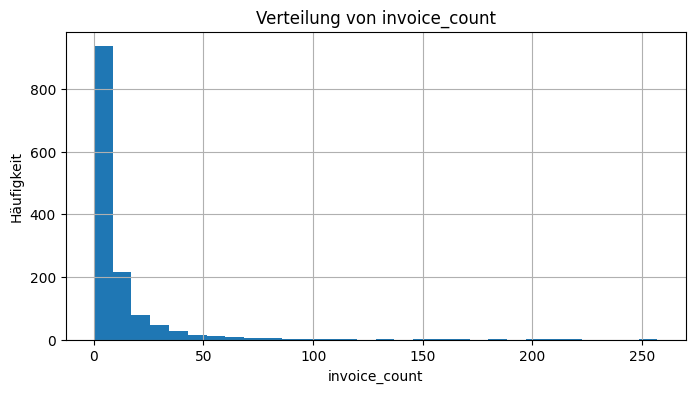

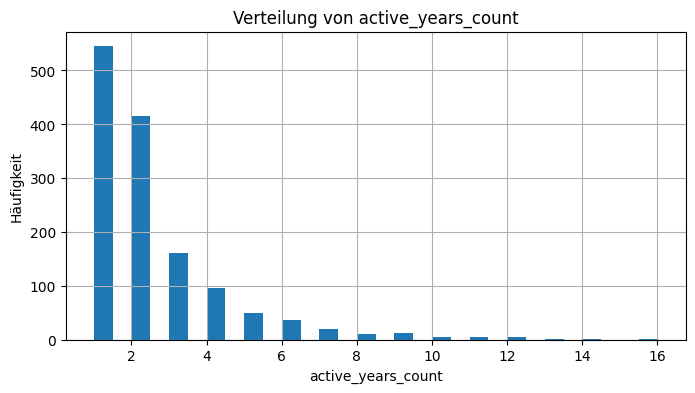

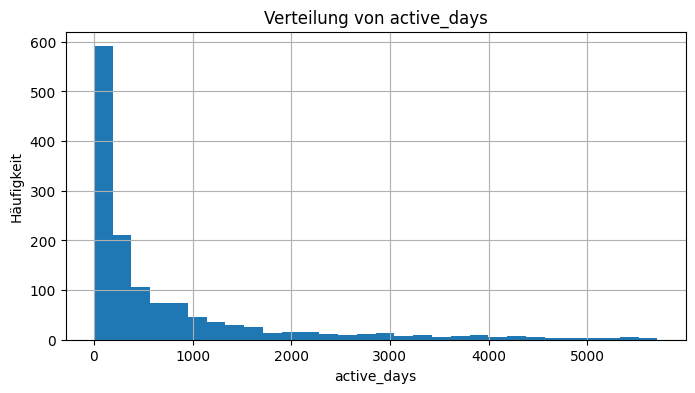

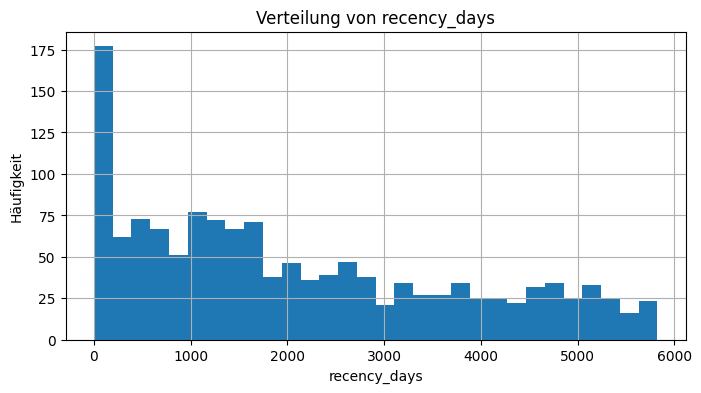

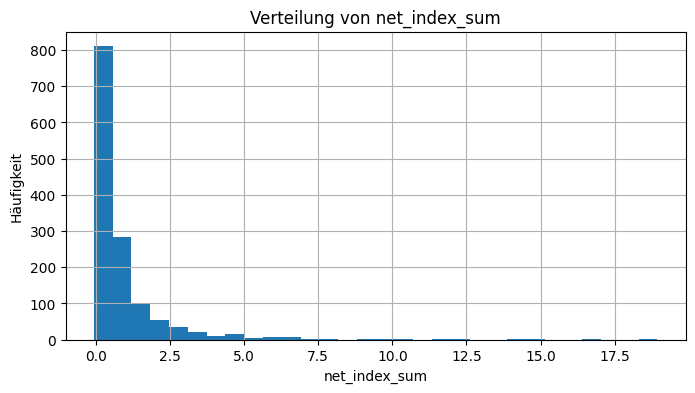

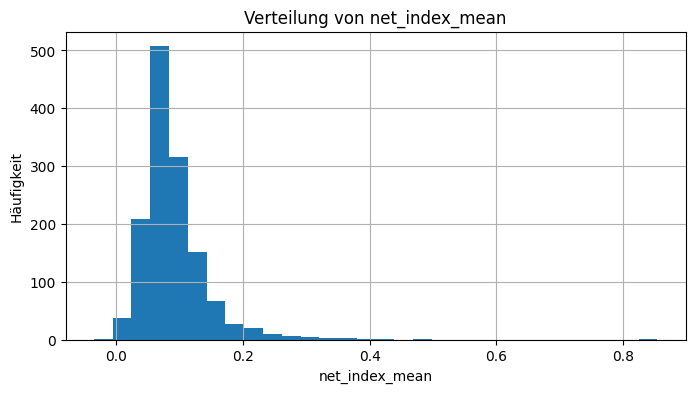

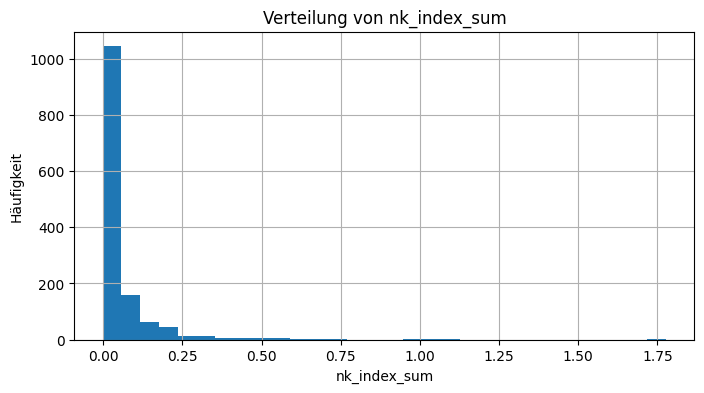

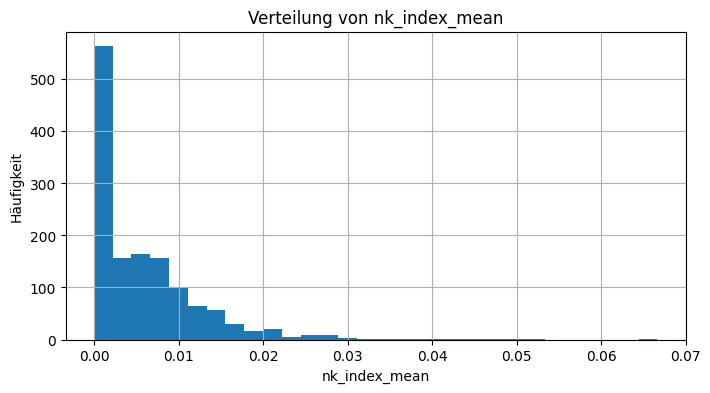

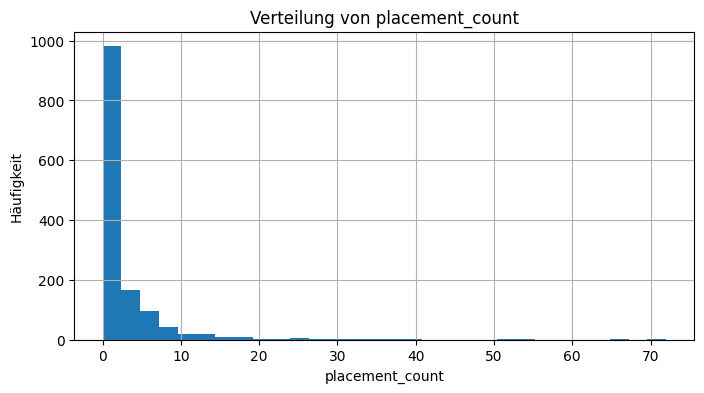

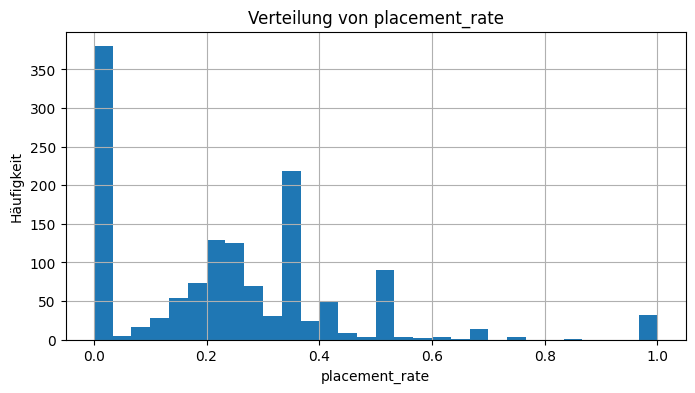

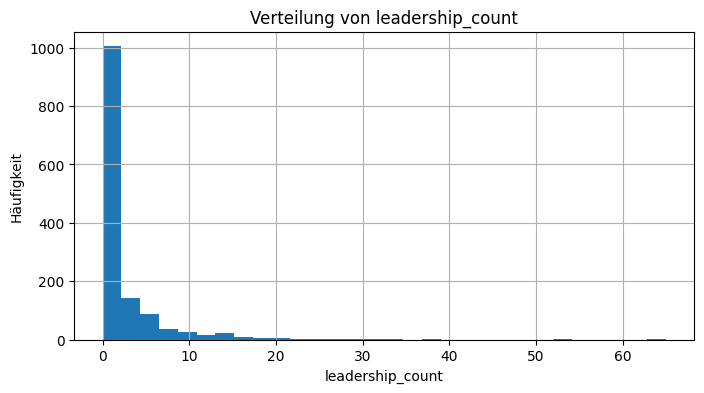

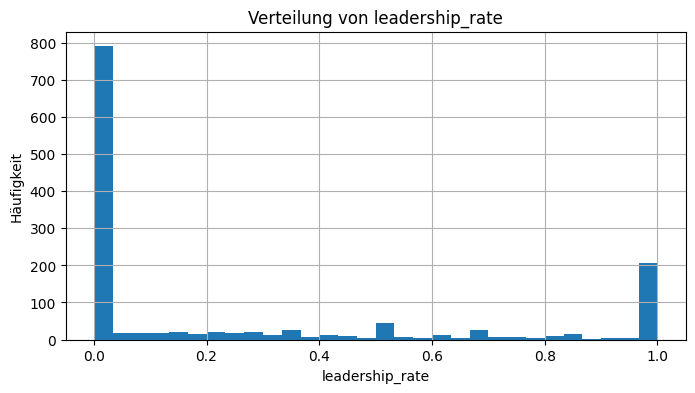

In [177]:
# Verteilungen zentraler numerischer Features

plot_cols = [
    "invoice_count",
    "active_years_count",
    "active_days",
    "recency_days",
    "net_index_sum",
    "net_index_mean",
    "nk_index_sum",
    "nk_index_mean",
    "placement_count",
    "placement_rate",
    "leadership_count",
    "leadership_rate"
]

plot_cols = [col for col in plot_cols if col in eda_df.columns]

for col in plot_cols:
    plt.figure(figsize=(8, 4))
    eda_df[col].dropna().hist(bins=30)
    plt.title(f"Verteilung von {col}")
    plt.xlabel(col)
    plt.ylabel("Häufigkeit")
    plt.show()

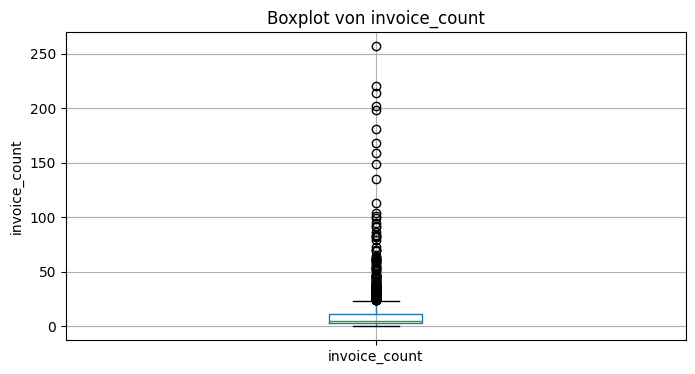

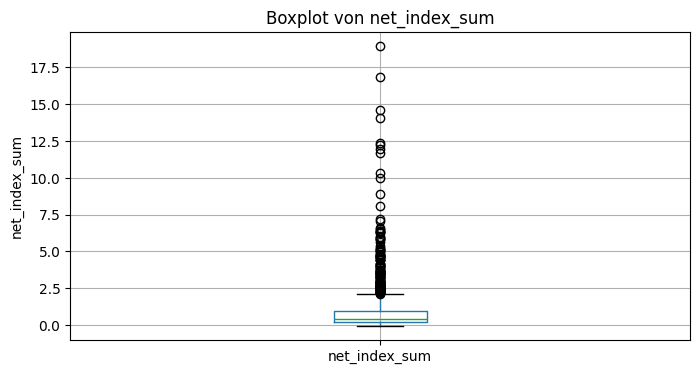

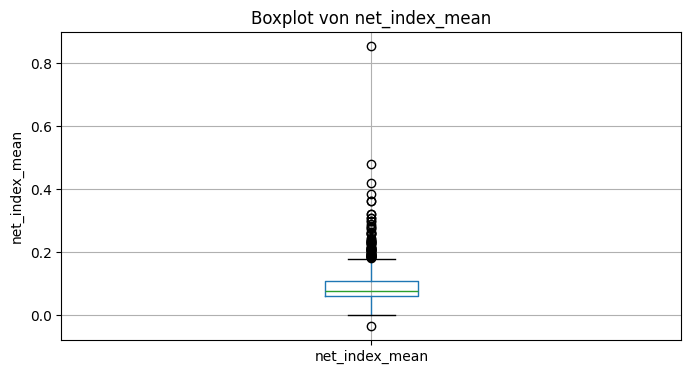

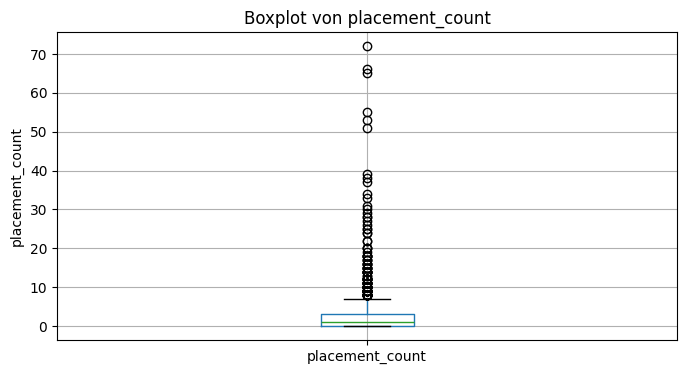

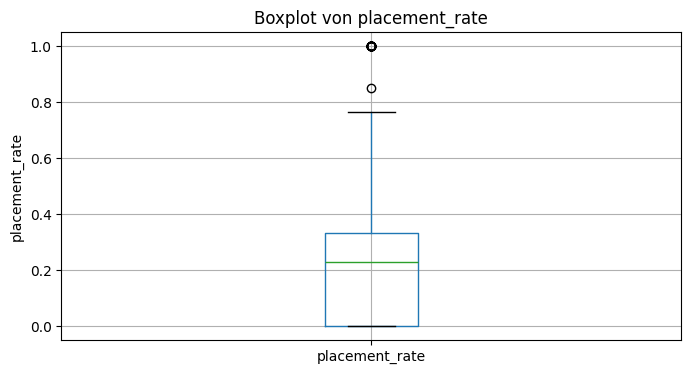

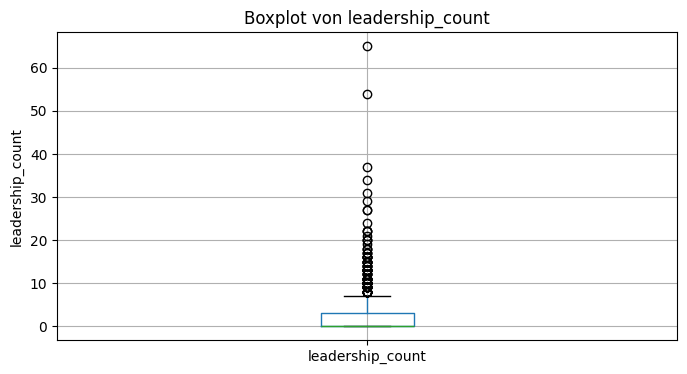

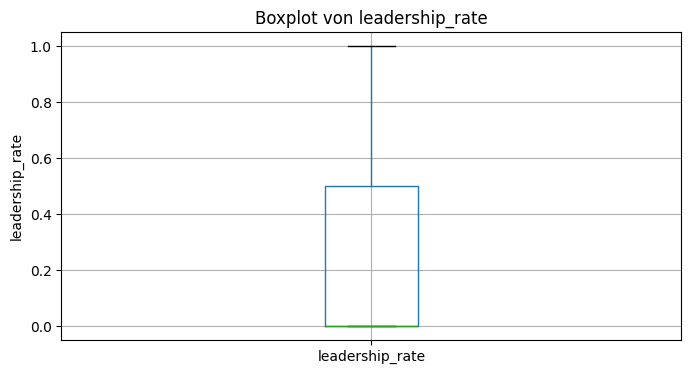

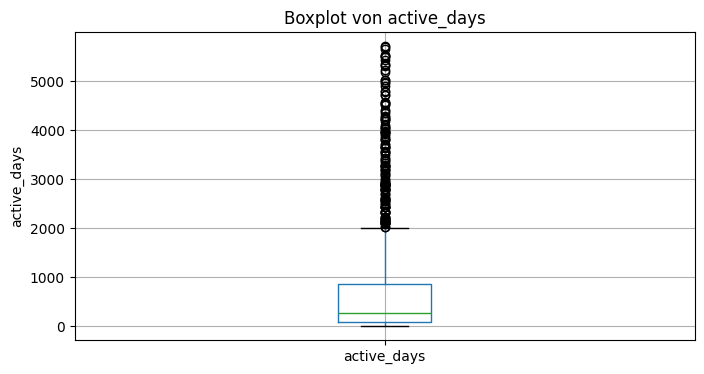

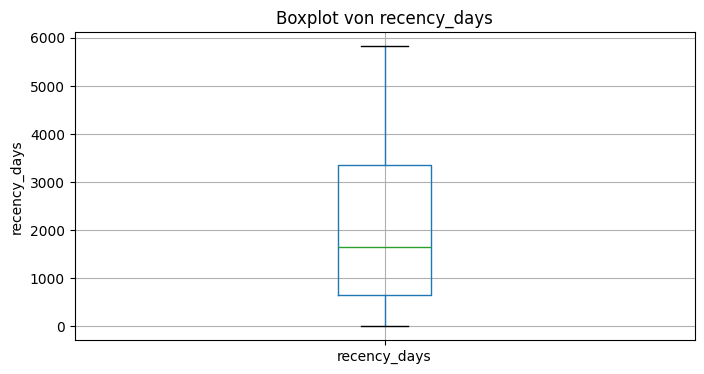

In [178]:
# Boxplots für ausgewählte Kernmerkmale

boxplot_cols = [
    "invoice_count",
    "net_index_sum",
    "net_index_mean",
    "placement_count",
    "placement_rate",
    "leadership_count",
    "leadership_rate",
    "active_days",
    "recency_days"
]

boxplot_cols = [col for col in boxplot_cols if col in eda_df.columns]

for col in boxplot_cols:
    plt.figure(figsize=(8, 4))
    eda_df.boxplot(column=col)
    plt.title(f"Boxplot von {col}")
    plt.ylabel(col)
    plt.show()

In [179]:
# Häufigkeiten zentraler kategorialer Merkmale

categorical_check_cols = [
    "dominant_contract_type",
    "dominant_revenue_subtype",
    "dominant_job_category",
    "dominant_industry"
]

categorical_check_cols = [col for col in categorical_check_cols if col in eda_df.columns]

for col in categorical_check_cols:
    print(f"\nHäufigkeiten für {col}:")
    display(eda_df[col].value_counts(dropna=False).to_frame("count").head(15))


Häufigkeiten für dominant_contract_type:


,count
dominant_contract_type,
Prozent - 3 Raten,747
Pauschal - 3 Raten,323
Prozent mit Anzahlung,120
Pauschal mit Anzahlung,81
Pauschalhonorar,42
Prozentualhonorar,24
N/V,16
Pauschal - 4 Raten,5
Prozent - 4 Raten,4



Häufigkeiten für dominant_revenue_subtype:


,count
dominant_revenue_subtype,
Start,506
Abschluss,303
Präsentation,263
Gutschrift,73
Abbruch,68
Wertberichtigung,53
Erfolgsauftrag,44
Kostenpauschale,19
Nebenkostenpauschale,7



Häufigkeiten für dominant_job_category:


,count
dominant_job_category,
Vertrieb/Presales/Marketing,505
Spezialist (Kerngeschäft),392
C-Level,242
Corporate Services,130
Internal IT,83
Sonstige,8
N/V,4



Häufigkeiten für dominant_industry:


,count
dominant_industry,
Digital & Technology,724
Industrial,262
Financial Services,115
Professional Services,102
Consumer Industries,88
Life Science,47
Sonstige,15
Public Sector,7
N/V,4


In [180]:
# Erste Arbeitsnotizen für die nächsten Schritte

print("- Prüfen, ob invoice_count = 0 auf fehlende Rechnungsnummern oder auf eine fachliche Sonderlogik zurückgeht.")
print("- Negative monetäre Summen fachlich einordnen, zum Beispiel als Gutschrift, Storno oder Korrekturbuchung.")
print("- Stark schiefe Verteilungen als Kandidaten für spätere Transformation oder robuste Verfahren vormerken.")
print("- Features mit hoher Null-Rate auf ihren tatsächlichen Zusatznutzen prüfen.")
print("- Seltene oder uneinheitliche Kategorien für das Data Cleaning vormerken.")

- Prüfen, ob invoice_count = 0 auf fehlende Rechnungsnummern oder auf eine fachliche Sonderlogik zurückgeht.
- Negative monetäre Summen fachlich einordnen, zum Beispiel als Gutschrift, Storno oder Korrekturbuchung.
- Stark schiefe Verteilungen als Kandidaten für spätere Transformation oder robuste Verfahren vormerken.
- Features mit hoher Null-Rate auf ihren tatsächlichen Zusatznutzen prüfen.
- Seltene oder uneinheitliche Kategorien für das Data Cleaning vormerken.


## Data Cleaning auf Debitor-Ebene

In [181]:
clean_df = debitor_features.copy()

print("Start Data Cleaning")
print(f"Ausgangsbestand Debitoren: {len(clean_df)}")

Start Data Cleaning
Ausgangsbestand Debitoren: 1364


In [182]:
# N/V als fehlende Angabe behandeln

categorical_clean_cols = [
    "dominant_contract_type",
    "dominant_revenue_subtype",
    "dominant_job_category",
    "dominant_industry"
]

categorical_clean_cols = [col for col in categorical_clean_cols if col in clean_df.columns]

for col in categorical_clean_cols:
    nv_count = (clean_df[col] == "N/V").sum()
    print(f"{col}: N/V vor Bereinigung = {nv_count}")
    clean_df[col] = clean_df[col].replace("N/V", np.nan)

print("\nN/V-Bereinigung abgeschlossen.")

dominant_contract_type: N/V vor Bereinigung = 16
dominant_revenue_subtype: N/V vor Bereinigung = 1
dominant_job_category: N/V vor Bereinigung = 4
dominant_industry: N/V vor Bereinigung = 4

N/V-Bereinigung abgeschlossen.


In [183]:
# Debitoren ohne relevante Rechnungsbasis ausschließen

if "invoice_count" in clean_df.columns:
    excluded_invoice_zero = clean_df[clean_df["invoice_count"] == 0].copy()
    clean_df = clean_df[clean_df["invoice_count"] > 0].copy()

    print(f"Ausgeschlossene Debitoren wegen invoice_count == 0: {len(excluded_invoice_zero)}")
    print(f"Debitorenbestand nach invoice_count-Filter: {len(clean_df)}")
else:
    excluded_invoice_zero = pd.DataFrame()
    print("Spalte 'invoice_count' nicht gefunden.")

Ausgeschlossene Debitoren wegen invoice_count == 0: 1
Debitorenbestand nach invoice_count-Filter: 1363


In [184]:
# Debitoren mit negativem Umsatzbezug ausschließen

if "net_index_sum" in clean_df.columns:
    excluded_negative_net = clean_df[clean_df["net_index_sum"] < 0].copy()
    clean_df = clean_df[clean_df["net_index_sum"] >= 0].copy()

    print(f"Ausgeschlossene Debitoren wegen net_index_sum < 0: {len(excluded_negative_net)}")
    print(f"Debitorenbestand nach net_index_sum-Filter: {len(clean_df)}")
else:
    excluded_negative_net = pd.DataFrame()
    print("Spalte 'net_index_sum' nicht gefunden.")

Ausgeschlossene Debitoren wegen net_index_sum < 0: 1
Debitorenbestand nach net_index_sum-Filter: 1362


In [185]:
# Debitoren mit negativem Nebenkostenbezug ausschließen

if "nk_index_sum" in clean_df.columns:
    excluded_negative_nk = clean_df[clean_df["nk_index_sum"] < 0].copy()
    clean_df = clean_df[clean_df["nk_index_sum"] >= 0].copy()

    print(f"Ausgeschlossene Debitoren wegen nk_index_sum < 0: {len(excluded_negative_nk)}")
    print(f"Debitorenbestand nach nk_index_sum-Filter: {len(clean_df)}")
else:
    excluded_negative_nk = pd.DataFrame()
    print("Spalte 'nk_index_sum' nicht gefunden.")

Ausgeschlossene Debitoren wegen nk_index_sum < 0: 1
Debitorenbestand nach nk_index_sum-Filter: 1361


In [186]:
# Überblick über ausgeschlossene Fälle

excluded_cases = []

if len(excluded_invoice_zero) > 0:
    temp = excluded_invoice_zero.copy()
    temp["exclusion_reason"] = "invoice_count == 0"
    excluded_cases.append(temp)

if len(excluded_negative_net) > 0:
    temp = excluded_negative_net.copy()
    temp["exclusion_reason"] = "net_index_sum < 0"
    excluded_cases.append(temp)

if len(excluded_negative_nk) > 0:
    temp = excluded_negative_nk.copy()
    temp["exclusion_reason"] = "nk_index_sum < 0"
    excluded_cases.append(temp)

if excluded_cases:
    excluded_df = pd.concat(excluded_cases, ignore_index=True)
    print(f"Gesamtzahl ausgeschlossener Fälle: {len(excluded_df)}")
    display(excluded_df.head(20))
else:
    excluded_df = pd.DataFrame()
    print("Keine Fälle ausgeschlossen.")

Gesamtzahl ausgeschlossener Fälle: 3


,Debitor,invoice_count,first_invoice_date,last_invoice_date,active_years_count,net_index_sum,net_index_mean,nk_index_sum,nk_index_mean,placement_count,placement_rate,leadership_count,leadership_rate,dominant_contract_type,dominant_revenue_subtype,dominant_job_category,dominant_industry,active_days,recency_days,exclusion_reason
0,Debitor 128,0,2012-03-06,2012-03-06,1,0.000000,0.000000,0.000000,0.000000,1,1.000000,0,0.000000,NaN,Replacement,Corporate Services,Professional Services,0,5048,invoice_count == 0
1,Debitor 368,2,2010-06-11,2010-06-11,1,-0.071368,-0.035684,0.000000,0.000000,0,0.000000,0,0.000000,Prozent mit Anzahlung,Abbruch,C-Level,Industrial,0,5682,net_index_sum < 0
2,Debitor 1231,46,2013-12-30,2022-10-19,10,1.675676,0.036428,-0.002082,-0.000045,10,0.217391,8,0.173913,Pauschal - 3 Raten,Start,C-Level,Professional Services,3215,1169,nk_index_sum < 0


In [187]:
# Bereinigte Matrix als neue Arbeitsbasis festhalten

debitor_features_clean = clean_df.copy()

print("Bereinigte Debitor-Matrix erstellt.")
print(f"Anzahl Debitoren nach Cleaning: {len(debitor_features_clean)}")
print(f"Anzahl Features nach Cleaning: {debitor_features_clean.shape[1]}")

Bereinigte Debitor-Matrix erstellt.
Anzahl Debitoren nach Cleaning: 1361
Anzahl Features nach Cleaning: 19


In [188]:
# Kurzprüfung nach dem Cleaning

print("Prüfung nach dem Cleaning:")

if "invoice_count" in debitor_features_clean.columns:
    print("invoice_count == 0:", (debitor_features_clean["invoice_count"] == 0).sum())

if "net_index_sum" in debitor_features_clean.columns:
    print("net_index_sum < 0:", (debitor_features_clean["net_index_sum"] < 0).sum())

if "nk_index_sum" in debitor_features_clean.columns:
    print("nk_index_sum < 0:", (debitor_features_clean["nk_index_sum"] < 0).sum())

for col in categorical_clean_cols:
    if col in debitor_features_clean.columns:
        print(f"N/V in {col}:", (debitor_features_clean[col] == "N/V").sum())

Prüfung nach dem Cleaning:
invoice_count == 0: 0
net_index_sum < 0: 0
nk_index_sum < 0: 0
N/V in dominant_contract_type: 0
N/V in dominant_revenue_subtype: 0
N/V in dominant_job_category: 0
N/V in dominant_industry: 0


In [189]:
# Fehlwerte nach der kategorialen Bereinigung erneut prüfen

missing_after_cleaning = pd.DataFrame({
    "missing_count": debitor_features_clean.isna().sum(),
    "missing_pct": (debitor_features_clean.isna().sum() / len(debitor_features_clean) * 100).round(2)
}).sort_values("missing_count", ascending=False)

missing_after_cleaning[missing_after_cleaning["missing_count"] > 0]

,missing_count,missing_pct
dominant_contract_type,15,1.10
dominant_job_category,4,0.29
dominant_industry,4,0.29
dominant_revenue_subtype,1,0.07


In [190]:
# Kurze methodische Notiz zum Cleaning

print("- Debitoren ohne relevante Rechnungsbasis wurden ausgeschlossen.")
print("- Debitoren mit negativem Umsatz- oder Nebenkostenbezug wurden ausgeschlossen.")
print("- N/V wurde in dominanten kategorialen Feldern als fehlende Angabe behandelt.")
print("- Echte numerische Nullwerte wurden beibehalten.")
print("- Die bereinigte Matrix bildet die Grundlage für das nächste Feature Engineering.")

- Debitoren ohne relevante Rechnungsbasis wurden ausgeschlossen.
- Debitoren mit negativem Umsatz- oder Nebenkostenbezug wurden ausgeschlossen.
- N/V wurde in dominanten kategorialen Feldern als fehlende Angabe behandelt.
- Echte numerische Nullwerte wurden beibehalten.
- Die bereinigte Matrix bildet die Grundlage für das nächste Feature Engineering.


In [191]:
# Feature Engineering auf Debitor-Ebene vorbereiten

debitor_features_fe = debitor_features_clean.copy()

print("Ausgangsbasis für Feature Engineering:")
print(f"Debitoren: {debitor_features_fe.shape[0]}")
print(f"Features: {debitor_features_fe.shape[1]}")

Ausgangsbasis für Feature Engineering:
Debitoren: 1361
Features: 19


In [192]:
# Neue Aktivitäts- und Intensitätsmerkmale ableiten

if "invoice_count" in debitor_features_fe.columns and "active_years_count" in debitor_features_fe.columns:
    debitor_features_fe["invoices_per_active_year"] = (
        debitor_features_fe["invoice_count"] / debitor_features_fe["active_years_count"].replace(0, np.nan)
    )

if "net_index_sum" in debitor_features_fe.columns and "active_years_count" in debitor_features_fe.columns:
    debitor_features_fe["net_per_active_year"] = (
        debitor_features_fe["net_index_sum"] / debitor_features_fe["active_years_count"].replace(0, np.nan)
    )

if "placement_count" in debitor_features_fe.columns and "active_years_count" in debitor_features_fe.columns:
    debitor_features_fe["placements_per_active_year"] = (
        debitor_features_fe["placement_count"] / debitor_features_fe["active_years_count"].replace(0, np.nan)
    )

if "leadership_count" in debitor_features_fe.columns and "active_years_count" in debitor_features_fe.columns:
    debitor_features_fe["leadership_per_active_year"] = (
        debitor_features_fe["leadership_count"] / debitor_features_fe["active_years_count"].replace(0, np.nan)
    )

if "net_index_sum" in debitor_features_fe.columns and "invoice_count" in debitor_features_fe.columns:
    debitor_features_fe["net_per_invoice"] = (
        debitor_features_fe["net_index_sum"] / debitor_features_fe["invoice_count"].replace(0, np.nan)
    )

print("Neue Aktivitäts- und Intensitätsmerkmale wurden ergänzt.")

Neue Aktivitäts- und Intensitätsmerkmale wurden ergänzt.


In [193]:
# Vorhandene Diversitätsmerkmale prüfen

diversity_cols = [
    "contract_type_nunique",
    "revenue_subtype_nunique",
    "job_category_nunique",
    "industry_nunique"
]

available_diversity_cols = [col for col in diversity_cols if col in debitor_features_fe.columns]

print("Verfügbare Diversitätsmerkmale:")
print(available_diversity_cols)

Verfügbare Diversitätsmerkmale:
[]


In [194]:
# Neue Feature-Spalten sichtbar machen

new_feature_cols = [
    "invoices_per_active_year",
    "net_per_active_year",
    "placements_per_active_year",
    "leadership_per_active_year",
    "net_per_invoice"
]

new_feature_cols = [col for col in new_feature_cols if col in debitor_features_fe.columns]

print("Neu abgeleitete Features:")
print(new_feature_cols)

Neu abgeleitete Features:
['invoices_per_active_year', 'net_per_active_year', 'placements_per_active_year', 'leadership_per_active_year', 'net_per_invoice']


In [195]:
# Deskriptive Statistik der neuen Features

if new_feature_cols:
    debitor_features_fe[new_feature_cols].describe().T
else:
    print("Keine neuen Features vorhanden.")

In [196]:
# Fehlwerte in den neuen Features prüfen

if new_feature_cols:
    missing_new_features = pd.DataFrame({
        "missing_count": debitor_features_fe[new_feature_cols].isna().sum(),
        "missing_pct": (debitor_features_fe[new_feature_cols].isna().sum() / len(debitor_features_fe) * 100).round(2)
    }).sort_values("missing_count", ascending=False)

    missing_new_features[missing_new_features["missing_count"] > 0]
else:
    print("Keine neuen Features vorhanden.")

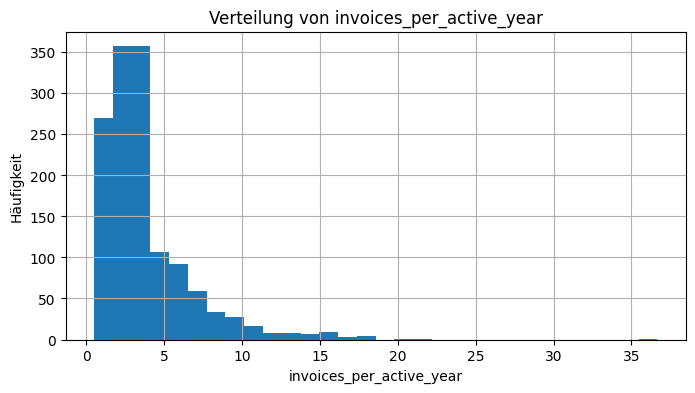

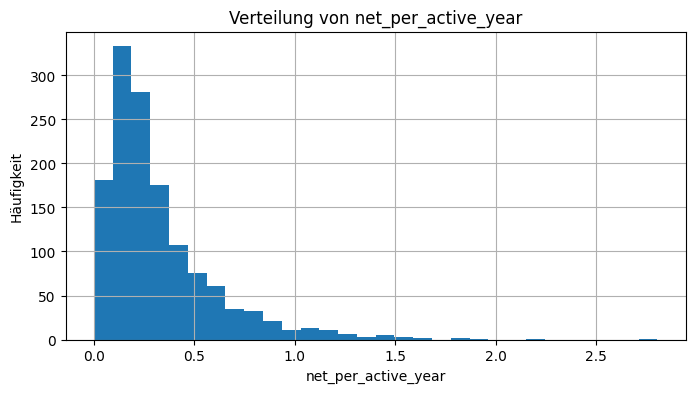

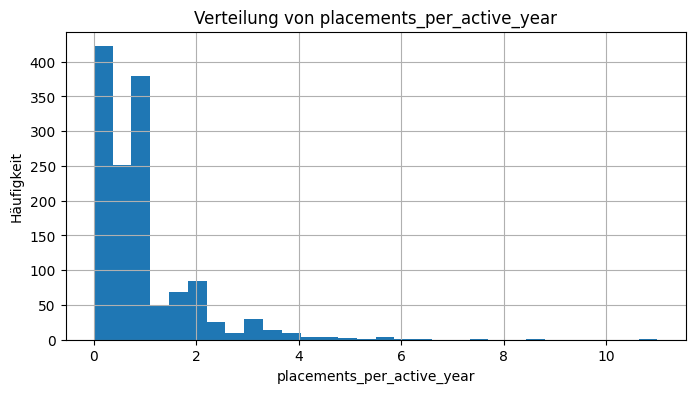

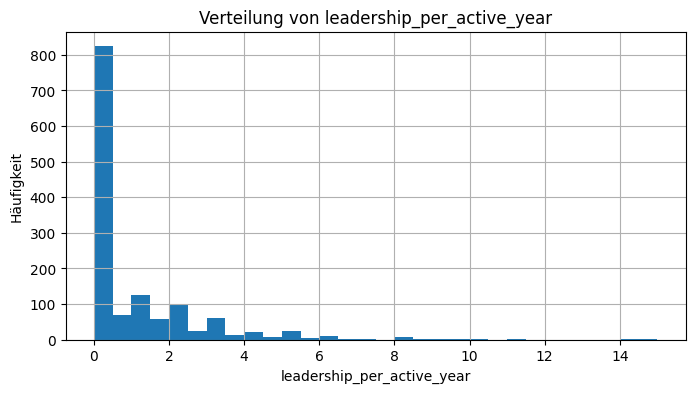

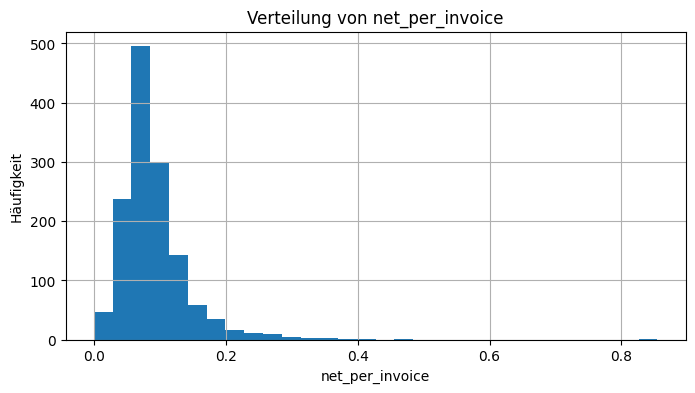

In [197]:
# Verteilungen der neuen Features prüfen

for col in new_feature_cols:
    plt.figure(figsize=(8, 4))
    debitor_features_fe[col].dropna().hist(bins=30)
    plt.title(f"Verteilung von {col}")
    plt.xlabel(col)
    plt.ylabel("Häufigkeit")
    plt.show()

In [198]:
# Feature-Engineering-Stand als neue Arbeitsbasis festhalten

debitor_features_final = debitor_features_fe.copy()

print("Feature Engineering abgeschlossen.")
print(f"Debitoren: {debitor_features_final.shape[0]}")
print(f"Features: {debitor_features_final.shape[1]}")

Feature Engineering abgeschlossen.
Debitoren: 1361
Features: 24


In [199]:
# Arbeitsbasis für die Baseline-Modellierung vorbereiten

baseline_df = debitor_features_final.copy()

print("Ausgangsbasis für die Baseline-Modellierung:")
print(f"Debitoren: {baseline_df.shape[0]}")
print(f"Features: {baseline_df.shape[1]}")

Ausgangsbasis für die Baseline-Modellierung:
Debitoren: 1361
Features: 24


In [200]:
# Numerische Kernfeatures für die Baseline festlegen

baseline_feature_candidates = [
    "invoice_count",
    "active_years_count",
    "active_days",
    "recency_days",
    "net_index_sum",
    "net_index_mean",
    "nk_index_sum",
    "nk_index_mean",
    "placement_count",
    "placement_rate",
    "leadership_count",
    "leadership_rate",
    "invoices_per_active_year",
    "net_per_active_year",
    "placements_per_active_year",
    "leadership_per_active_year",
    "net_per_invoice",
    "revenue_subtype_nunique",
    "job_category_nunique",
    "industry_nunique"
]

baseline_feature_cols = [col for col in baseline_feature_candidates if col in baseline_df.columns]

print("Numerische Kernfeatures für die Baseline:")
print(baseline_feature_cols)

Numerische Kernfeatures für die Baseline:
['invoice_count', 'active_years_count', 'active_days', 'recency_days', 'net_index_sum', 'net_index_mean', 'nk_index_sum', 'nk_index_mean', 'placement_count', 'placement_rate', 'leadership_count', 'leadership_rate', 'invoices_per_active_year', 'net_per_active_year', 'placements_per_active_year', 'leadership_per_active_year', 'net_per_invoice']


In [201]:
# Erste Baseline-Feature-Matrix erzeugen

X_baseline_raw = baseline_df[baseline_feature_cols].copy()

print("Form der Baseline-Feature-Matrix:")
print(X_baseline_raw.shape)

X_baseline_raw.head()

Form der Baseline-Feature-Matrix:
(1361, 17)


,invoice_count,active_years_count,active_days,recency_days,net_index_sum,net_index_mean,nk_index_sum,nk_index_mean,placement_count,placement_rate,leadership_count,leadership_rate,invoices_per_active_year,net_per_active_year,placements_per_active_year,leadership_per_active_year,net_per_invoice
0,101,16,5481,34,5.974359,0.059152,0.581197,0.005754,30,0.29703,0,0.000000,6.312500,0.373397,1.875000,0.000000,0.059152
1,1,1,0,2591,0.042735,0.042735,0.000000,0.000000,1,1.00000,0,0.000000,1.000000,0.042735,1.000000,0.000000,0.042735
2,36,7,2872,96,2.910427,0.080845,0.338704,0.009408,9,0.25000,12,0.333333,5.142857,0.415775,1.285714,1.714286,0.080845
3,2,2,141,4668,0.153846,0.076923,0.002564,0.001282,1,0.50000,0,0.000000,1.000000,0.076923,0.500000,0.000000,0.076923
4,4,1,110,5160,0.307692,0.076923,0.000000,0.000000,0,0.00000,0,0.000000,4.000000,0.307692,0.000000,0.000000,0.076923


In [202]:
# Fehlwerte in der Baseline-Feature-Matrix prüfen

missing_baseline = pd.DataFrame({
    "missing_count": X_baseline_raw.isna().sum(),
    "missing_pct": (X_baseline_raw.isna().sum() / len(X_baseline_raw) * 100).round(2)
}).sort_values("missing_count", ascending=False)

missing_baseline[missing_baseline["missing_count"] > 0]

,missing_count,missing_pct


In [203]:
# Fehlende numerische Werte für die Baseline pragmatisch behandeln

X_baseline_prepared = X_baseline_raw.copy()

for col in X_baseline_prepared.columns:
    if X_baseline_prepared[col].isna().sum() > 0:
        median_value = X_baseline_prepared[col].median()
        X_baseline_prepared[col] = X_baseline_prepared[col].fillna(median_value)

print("Fehlende Werte wurden für die Baseline mit dem Median gefüllt.")

Fehlende Werte wurden für die Baseline mit dem Median gefüllt.


In [204]:
# Baseline-Matrix nach der Imputation erneut prüfen

missing_baseline_after = pd.DataFrame({
    "missing_count": X_baseline_prepared.isna().sum(),
    "missing_pct": (X_baseline_prepared.isna().sum() / len(X_baseline_prepared) * 100).round(2)
}).sort_values("missing_count", ascending=False)

missing_baseline_after[missing_baseline_after["missing_count"] > 0]

,missing_count,missing_pct


In [205]:
# Baseline-Matrix standardisieren

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_baseline_scaled = pd.DataFrame(
    scaler.fit_transform(X_baseline_prepared),
    columns=X_baseline_prepared.columns,
    index=X_baseline_prepared.index
)

print("Standardisierte Baseline-Matrix erstellt.")
print(X_baseline_scaled.shape)

X_baseline_scaled.head()

Standardisierte Baseline-Matrix erstellt.
(1361, 17)


,invoice_count,active_years_count,active_days,recency_days,net_index_sum,net_index_mean,nk_index_sum,nk_index_mean,placement_count,placement_rate,leadership_count,leadership_rate,invoices_per_active_year,net_per_active_year,placements_per_active_year,leadership_per_active_year,net_per_invoice
0,4.342639,7.015599,4.380383,-1.230390,3.235321,-0.573096,4.792934,-0.001421,4.615278,0.321770,-0.477659,-0.686660,0.835642,0.172117,0.975413,-0.559196,-0.576122
1,-0.489616,-0.714510,-0.670100,0.301183,-0.561413,-0.879852,-0.474437,-0.789423,-0.314371,3.748040,-0.477659,-0.686660,-0.903567,-0.972251,0.102314,-0.559196,-0.883097
2,1.201673,2.377534,1.976312,-1.193253,1.274149,-0.167755,2.595232,0.498957,1.045532,0.092548,2.102077,0.194965,0.452724,0.318780,0.387407,0.460181,-0.170492
3,-0.441294,-0.199169,-0.540175,1.545249,-0.490293,-0.241041,-0.451198,-0.613861,-0.314371,1.311045,-0.477659,-0.686660,-0.903567,-0.853932,-0.396600,-0.559196,-0.243830
4,-0.344649,-0.714510,-0.568740,1.839943,-0.391818,-0.241041,-0.474437,-0.789423,-0.484359,-1.125950,-0.477659,-0.686660,0.078575,-0.055278,-0.895514,-0.559196,-0.243830


In [206]:
# Standardisierung grob prüfen

scaling_check = pd.DataFrame({
    "mean_after_scaling": X_baseline_scaled.mean().round(4),
    "std_after_scaling": X_baseline_scaled.std().round(4)
})

scaling_check.head(10)

,mean_after_scaling,std_after_scaling
invoice_count,-0.0,1.0004
active_years_count,0.0,1.0004
active_days,0.0,1.0004
recency_days,-0.0,1.0004
net_index_sum,0.0,1.0004
net_index_mean,0.0,1.0004
nk_index_sum,-0.0,1.0004
nk_index_mean,-0.0,1.0004
placement_count,-0.0,1.0004
placement_rate,0.0,1.0004


In [207]:
# Eingesetzte Baseline-Features dokumentieren

baseline_feature_overview = pd.DataFrame({
    "feature": baseline_feature_cols
})

baseline_feature_overview

,feature
0,invoice_count
1,active_years_count
2,active_days
3,recency_days
4,net_index_sum
5,net_index_mean
6,nk_index_sum
7,nk_index_mean
8,placement_count
9,placement_rate


In [208]:
# Methodische Notiz zur Baseline

print("Methodische Notiz zur Baseline:")
print("- Für die erste Baseline wurden bewusst nur numerische Kernfeatures verwendet.")
print("- Dominante kategoriale Felder wurden in diesem Schritt noch nicht einbezogen.")
print("- Vertragsarten wurden bewusst nicht in den Vordergrund gestellt.")
print("- Fehlende Werte in numerischen Baseline-Features wurden pragmatisch mit dem Median behandelt.")
print("- Die standardisierte Baseline-Matrix bildet die Grundlage für die Auswahl und Prüfung erster Clusterverfahren.")

Methodische Notiz zur Baseline:
- Für die erste Baseline wurden bewusst nur numerische Kernfeatures verwendet.
- Dominante kategoriale Felder wurden in diesem Schritt noch nicht einbezogen.
- Vertragsarten wurden bewusst nicht in den Vordergrund gestellt.
- Fehlende Werte in numerischen Baseline-Features wurden pragmatisch mit dem Median behandelt.
- Die standardisierte Baseline-Matrix bildet die Grundlage für die Auswahl und Prüfung erster Clusterverfahren.


In [209]:
# Arbeitsbasis für das Clustering vorbereiten

clustering_df = debitor_features_final.copy()

print("Ausgangsbasis für das Clustering:")
print(f"Debitoren: {clustering_df.shape[0]}")
print(f"Features: {clustering_df.shape[1]}")
print(f"Baseline-Matrix: {X_baseline_scaled.shape}")

Ausgangsbasis für das Clustering:
Debitoren: 1361
Features: 24
Baseline-Matrix: (1361, 17)


In [210]:
# K-Means für erste Clusterläufe vorbereiten

from sklearn.cluster import KMeans

In [211]:
# Erste K-Means-Läufe für verschiedene Clusterzahlen durchführen

k_values = range(2, 9)

kmeans_runs = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_baseline_scaled)
    
    kmeans_runs.append({
        "k": k,
        "inertia": kmeans.inertia_
    })

kmeans_runs_df = pd.DataFrame(kmeans_runs)
kmeans_runs_df

,k,inertia
0,2,17968.326372
1,3,15259.770275
2,4,13523.830420
3,5,12348.965367
4,6,11381.678078
5,7,10546.171849
6,8,9803.078330


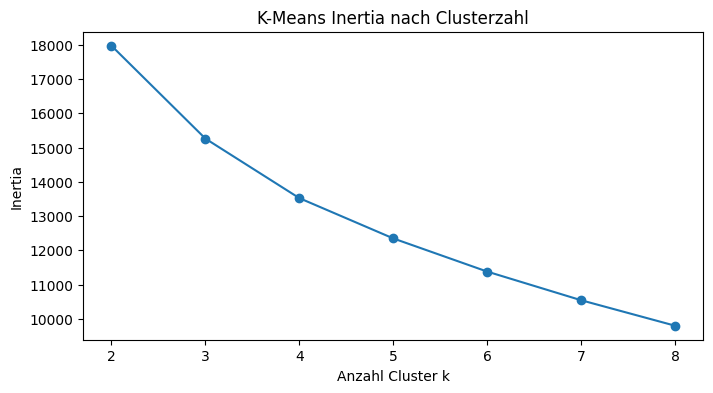

In [212]:
# Inertia für verschiedene Clusterzahlen visualisieren

plt.figure(figsize=(8, 4))
plt.plot(kmeans_runs_df["k"], kmeans_runs_df["inertia"], marker="o")
plt.title("K-Means Inertia nach Clusterzahl")
plt.xlabel("Anzahl Cluster k")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.show()

In [213]:
# Erste Arbeits-Clusterzahl festlegen

k_selected = 4

print(f"Gewählte Arbeits-Clusterzahl: {k_selected}")

Gewählte Arbeits-Clusterzahl: 4


In [214]:
# K-Means mit der gewählten Clusterzahl ausführen

kmeans_final = KMeans(n_clusters=k_selected, random_state=42, n_init=10)
cluster_labels_final = kmeans_final.fit_predict(X_baseline_scaled)

print("K-Means-Lauf abgeschlossen.")
print(f"Anzahl Cluster: {k_selected}")

K-Means-Lauf abgeschlossen.
Anzahl Cluster: 4


In [215]:
# Clusterlabels an die Debitorbasis anhängen

clustering_df["cluster_kmeans"] = cluster_labels_final

print("Clusterlabels wurden ergänzt.")
clustering_df[["cluster_kmeans"]].head()

Clusterlabels wurden ergänzt.


,cluster_kmeans
0,3
1,1
2,0
3,1
4,1


In [216]:
# Clustergrößen prüfen

cluster_sizes = clustering_df["cluster_kmeans"].value_counts().sort_index().to_frame("count")
cluster_sizes

,count
cluster_kmeans,
0,232
1,766
2,342
3,21


In [217]:
# Erste numerische Clusterprofile berechnen

cluster_profile_means = clustering_df.groupby("cluster_kmeans")[baseline_feature_cols].mean().round(3)
cluster_profile_means

,invoice_count,active_years_count,active_days,recency_days,net_index_sum,net_index_mean,nk_index_sum,nk_index_mean,placement_count,placement_rate,leadership_count,leadership_rate,invoices_per_active_year,net_per_active_year,placements_per_active_year,leadership_per_active_year,net_per_invoice
cluster_kmeans,,,,,,,,,,,,,,,,,
0,28.375,4.853,2185.444,1358.164,2.394,0.090,0.127,0.004,7.970,0.289,4.573,0.166,6.456,0.557,1.846,0.999,0.090
1,5.000,1.779,373.641,2881.710,0.357,0.074,0.019,0.004,1.149,0.218,0.226,0.044,2.800,0.200,0.614,0.107,0.074
2,5.424,1.637,355.848,885.851,0.630,0.127,0.049,0.010,1.155,0.218,4.246,0.814,3.387,0.395,0.701,2.706,0.128
3,137.286,9.476,3562.667,788.143,9.867,0.073,0.520,0.004,35.905,0.264,16.095,0.138,15.070,1.102,3.963,1.910,0.073


In [218]:
# Clusterprofile auf standardisierter Basis berechnen

X_clustered_scaled = X_baseline_scaled.copy()
X_clustered_scaled["cluster_kmeans"] = cluster_labels_final

cluster_profile_scaled = X_clustered_scaled.groupby("cluster_kmeans").mean().round(3)
cluster_profile_scaled

,invoice_count,active_years_count,active_days,recency_days,net_index_sum,net_index_mean,nk_index_sum,nk_index_mean,placement_count,placement_rate,leadership_count,leadership_rate,invoices_per_active_year,net_per_active_year,placements_per_active_year,leadership_per_active_year,net_per_invoice
cluster_kmeans,,,,,,,,,,,,,,,,,
0,0.833,1.271,1.344,-0.437,0.943,-0.005,0.673,-0.175,0.870,0.281,0.505,-0.248,0.883,0.806,0.947,0.035,-0.003
1,-0.296,-0.313,-0.326,0.475,-0.360,-0.304,-0.305,-0.227,-0.289,-0.061,-0.429,-0.570,-0.314,-0.428,-0.283,-0.495,-0.305
2,-0.276,-0.386,-0.342,-0.720,-0.185,0.704,-0.035,0.643,-0.288,-0.063,0.435,1.465,-0.122,0.247,-0.196,1.050,0.704
3,6.096,3.654,2.613,-0.779,5.727,-0.313,4.240,-0.253,5.619,0.159,2.982,-0.321,3.703,2.694,3.059,0.576,-0.309


In [219]:
# Clustering-Ergebnis als neue Arbeitsbasis festhalten

clustering_results_df = clustering_df.copy()

print("Clustering-Arbeitsbasis erstellt.")
print(f"Debitoren: {clustering_results_df.shape[0]}")
print(f"Features inkl. Clusterlabel: {clustering_results_df.shape[1]}")

Clustering-Arbeitsbasis erstellt.
Debitoren: 1361
Features inkl. Clusterlabel: 25


In [ ]:
# Methodische Notiz zur Verfahrensauswahl

print("Methodische Notiz zur Clusterwahl:")
print("- Als erstes Clusterverfahren wurde K-Means als Baseline gewählt.")
print("- Die Clusterbildung basiert auf der standardisierten numerischen Baseline-Matrix.")
print("- Mehrere Clusterzahlen wurden zunächst explorativ über die Inertia verglichen.")
print("- Für die ersten inhaltlichen Prüfungen wurde eine Arbeits-Clusterzahl festgelegt.")
print("- Die formale Bewertung der Clusterqualität folgt im nächsten Schritt.")

Methodische Notiz zur Clusterwahl:
- Als erstes Clusterverfahren wurde K-Means als gut nachvollziehbare Baseline gewählt.
- Die Clusterbildung basiert auf der standardisierten numerischen Baseline-Matrix.
- Mehrere Clusterzahlen wurden zunächst explorativ über die Inertia verglichen.
- Für die ersten inhaltlichen Prüfungen wurde eine Arbeits-Clusterzahl festgelegt.
- Die formale Bewertung der Clusterqualität folgt im nächsten Schritt.


In [ ]:
# Validierungsmetriken für die Clusterqualität vorbereiten

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [ ]:
# Clusterqualität für verschiedene Clusterzahlen berechnen

k_values = range(2, 9)

cluster_validation_results = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_baseline_scaled)

    silhouette = silhouette_score(X_baseline_scaled, labels)
    davies_bouldin = davies_bouldin_score(X_baseline_scaled, labels)
    calinski_harabasz = calinski_harabasz_score(X_baseline_scaled, labels)

    cluster_validation_results.append({
        "k": k,
        "inertia": kmeans.inertia_,
        "silhouette_score": silhouette,
        "davies_bouldin_score": davies_bouldin,
        "calinski_harabasz_score": calinski_harabasz
    })

cluster_validation_df = pd.DataFrame(cluster_validation_results)
cluster_validation_df

In [ ]:
# Validierungsergebnisse gerundet darstellen

cluster_validation_df_rounded = cluster_validation_df.copy()

metric_cols = [
    "inertia",
    "silhouette_score",
    "davies_bouldin_score",
    "calinski_harabasz_score"
]

cluster_validation_df_rounded[metric_cols] = cluster_validation_df_rounded[metric_cols].round(4)
cluster_validation_df_rounded

In [ ]:
# Silhouette Score visualisieren

plt.figure(figsize=(8, 4))
plt.plot(cluster_validation_df["k"], cluster_validation_df["silhouette_score"], marker="o")
plt.title("Silhouette Score nach Clusterzahl")
plt.xlabel("Anzahl Cluster k")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.show()

In [ ]:
# Davies-Bouldin Score visualisieren

plt.figure(figsize=(8, 4))
plt.plot(cluster_validation_df["k"], cluster_validation_df["davies_bouldin_score"], marker="o")
plt.title("Davies-Bouldin Score nach Clusterzahl")
plt.xlabel("Anzahl Cluster k")
plt.ylabel("Davies-Bouldin Score")
plt.xticks(list(k_values))
plt.show()

In [ ]:
# Calinski-Harabasz Score visualisieren

plt.figure(figsize=(8, 4))
plt.plot(cluster_validation_df["k"], cluster_validation_df["calinski_harabasz_score"], marker="o")
plt.title("Calinski-Harabasz Score nach Clusterzahl")
plt.xlabel("Anzahl Cluster k")
plt.ylabel("Calinski-Harabasz Score")
plt.xticks(list(k_values))
plt.show()

In [ ]:
# Beste Clusterzahl je Metrik identifizieren

best_silhouette_k = cluster_validation_df.loc[cluster_validation_df["silhouette_score"].idxmax(), "k"]
best_davies_bouldin_k = cluster_validation_df.loc[cluster_validation_df["davies_bouldin_score"].idxmin(), "k"]
best_calinski_harabasz_k = cluster_validation_df.loc[cluster_validation_df["calinski_harabasz_score"].idxmax(), "k"]

print(f"Bestes k nach Silhouette Score: {best_silhouette_k}")
print(f"Bestes k nach Davies-Bouldin Score: {best_davies_bouldin_k}")
print(f"Bestes k nach Calinski-Harabasz Score: {best_calinski_harabasz_k}")

In [ ]:
# Aktuell gewählte Arbeits-Clusterzahl mit den Metriken abgleichen

selected_k_metrics = cluster_validation_df_rounded[cluster_validation_df_rounded["k"] == k_selected]
selected_k_metrics

In [ ]:
# Validierungsergebnisse als Arbeitsbasis festhalten

cluster_validation_results_df = cluster_validation_df.copy()

print("Validierungsergebnisse wurden als Arbeitsbasis gespeichert.")
print(cluster_validation_results_df.shape)

In [ ]:
# Methodische Notiz zur Clusterqualität

print("Methodische Notiz zur Clusterqualität:")
print("- Die Clusterqualität wurde für mehrere Clusterzahlen mit drei Standardmetriken geprüft.")
print("- Berücksichtigt wurden Silhouette Score, Davies-Bouldin Score und Calinski-Harabasz Score.")
print("- Die Metriken dienen als methodische Grundlage für die Wahl einer plausiblen Arbeits-Clusterzahl.")
print("- Die finale Entscheidung erfolgt nicht nur metrisch, sondern auch unter inhaltlicher Interpretierbarkeit der Cluster.")

In [ ]:
# Validierungsmetriken für die Clusterqualität vorbereiten

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [ ]:
# Clusterqualität für verschiedene Clusterzahlen berechnen

k_values = range(2, 9)

cluster_validation_results = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_baseline_scaled)

    cluster_validation_results.append({
        "k": k,
        "inertia": kmeans.inertia_,
        "silhouette_score": silhouette_score(X_baseline_scaled, labels),
        "davies_bouldin_score": davies_bouldin_score(X_baseline_scaled, labels),
        "calinski_harabasz_score": calinski_harabasz_score(X_baseline_scaled, labels)
    })

cluster_validation_df = pd.DataFrame(cluster_validation_results)
cluster_validation_df

In [ ]:
# Validierungsergebnisse gerundet darstellen

cluster_validation_df_rounded = cluster_validation_df.copy()

metric_cols = [
    "inertia",
    "silhouette_score",
    "davies_bouldin_score",
    "calinski_harabasz_score"
]

cluster_validation_df_rounded[metric_cols] = cluster_validation_df_rounded[metric_cols].round(4)
cluster_validation_df_rounded

In [ ]:
# Silhouette Score visualisieren

plt.figure(figsize=(8, 4))
plt.plot(cluster_validation_df["k"], cluster_validation_df["silhouette_score"], marker="o")
plt.title("Silhouette Score nach Clusterzahl")
plt.xlabel("Anzahl Cluster k")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.show()

In [ ]:
# Davies-Bouldin Score visualisieren

plt.figure(figsize=(8, 4))
plt.plot(cluster_validation_df["k"], cluster_validation_df["davies_bouldin_score"], marker="o")
plt.title("Davies-Bouldin Score nach Clusterzahl")
plt.xlabel("Anzahl Cluster k")
plt.ylabel("Davies-Bouldin Score")
plt.xticks(list(k_values))
plt.show()

In [ ]:
# Calinski-Harabasz Score visualisieren

plt.figure(figsize=(8, 4))
plt.plot(cluster_validation_df["k"], cluster_validation_df["calinski_harabasz_score"], marker="o")
plt.title("Calinski-Harabasz Score nach Clusterzahl")
plt.xlabel("Anzahl Cluster k")
plt.ylabel("Calinski-Harabasz Score")
plt.xticks(list(k_values))
plt.show()

In [ ]:
# Beste Clusterzahl je Metrik identifizieren

best_silhouette_k = cluster_validation_df.loc[cluster_validation_df["silhouette_score"].idxmax(), "k"]
best_davies_bouldin_k = cluster_validation_df.loc[cluster_validation_df["davies_bouldin_score"].idxmin(), "k"]
best_calinski_harabasz_k = cluster_validation_df.loc[cluster_validation_df["calinski_harabasz_score"].idxmax(), "k"]

print(f"Bestes k nach Silhouette Score: {best_silhouette_k}")
print(f"Bestes k nach Davies-Bouldin Score: {best_davies_bouldin_k}")
print(f"Bestes k nach Calinski-Harabasz Score: {best_calinski_harabasz_k}")

In [ ]:
# Aktuell gewählte Arbeits-Clusterzahl mit den Metriken abgleichen

selected_k_metrics = cluster_validation_df_rounded[cluster_validation_df_rounded["k"] == k_selected]
selected_k_metrics

In [ ]:
# Validierungsergebnisse als Arbeitsbasis festhalten

cluster_validation_results_df = cluster_validation_df.copy()

print("Validierungsergebnisse wurden als Arbeitsbasis gespeichert.")
print(cluster_validation_results_df.shape)

In [ ]:
# Methodische Notiz zur Clusterqualität

print("Methodische Notiz zur Clusterqualität:")
print("- Die Clusterqualität wurde für mehrere Clusterzahlen mit drei Standardmetriken geprüft.")
print("- Berücksichtigt wurden Silhouette Score, Davies-Bouldin Score und Calinski-Harabasz Score.")
print("- Die Metriken dienen als methodische Grundlage für die Wahl einer plausiblen Arbeits-Clusterzahl.")
print("- Die finale Entscheidung erfolgt nicht nur metrisch, sondern auch unter inhaltlicher Interpretierbarkeit der Cluster.")